Oppgave 2a)

In [ ]:
#INITIALISERING

#importering
import numpy as np
from matplotlib import pyplot as plt

#konstanter
params_oppave_2 = {
"beta_k"                : 1,
"antallPartikler"       : 101,
"antallSimulasjoner"    : 100,
"timeSteps"             : 200
}

In [507]:
#HJELPEFUNKSJONER

def lag_prob_tabeller(params):
    beta_k = params["beta_k"]

    #siden potensialfunksjonene er så simple finner vi at p_pos og p_neg er konstante for både V1 og V2 (altså uavhengig av x)
    prob_tabell_V_i = {
    "p_pos" : 1/3,
    "p_neg" : 1/3
    }

    prob_tabell_V_ii = {
    "p_pos" : 1/(1 + np.exp(-2*beta_k) + np.exp(-beta_k)),
    "p_neg" : np.exp(-2*beta_k) / (                          #må skrives slik for å ikke få overflow
        np.exp(-2*beta_k) + 1 + np.exp(-beta_k)
    )
    }
    return prob_tabell_V_i, prob_tabell_V_ii


#Oppgave 2a funksjoner
def particleWalk_uten_Repulsion_sim(prob_tabell, params):                           #kan være forskjellig potensialfunksjon
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]
    p_pos = prob_tabell["p_pos"]
    p_neg = prob_tabell["p_neg"]

    partiklerPos = np.arange(0,antallPartikler)
    for _ in range(timeSteps):
        for i in range(len(partiklerPos)):
            tilfeldigtall = np.random.rand()

            if tilfeldigtall <= p_neg:
                partiklerPos[i] -= 1
            elif tilfeldigtall >= (1-p_pos):
                partiklerPos[i] += 1

    return partiklerPos

#Oppgave 2b funksjoner
def particleWalk_med_Repulsion_sim(prob_tabell, params):
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]
    p_pos = prob_tabell["p_pos"]
    p_neg = prob_tabell["p_neg"]

    partiklerPos = np.arange(0,antallPartikler)
    partiklerPos_set = set(partiklerPos)

    for _ in range(timeSteps):
        tilfeldigRekkefølge = np.arange(0,antallPartikler)
        np.random.shuffle(tilfeldigRekkefølge)
        for i in tilfeldigRekkefølge:
            tilfeldigtall = np.random.rand()


            if tilfeldigtall <= p_neg:
                if (partiklerPos[i]-1) not in partiklerPos_set:
                    partiklerPos_set.add(partiklerPos[i]-1)
                    partiklerPos_set.remove(partiklerPos[i])
                    partiklerPos[i] -= 1
            elif tilfeldigtall >= (1-p_pos):
                if (partiklerPos[i]+1) not in partiklerPos_set:
                    partiklerPos_set.add(partiklerPos[i]+1)
                    partiklerPos_set.remove(partiklerPos[i])
                    partiklerPos[i] += 1

    return partiklerPos

In [508]:
#SIMULERINGSFUNKSJONER

#Oppgave 2a
def oppgave_2a(prob_tabell, params):
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]
    antallSimulasjoner = params["antallSimulasjoner"]

    totalPartikler = np.zeros(antallPartikler+2*timeSteps)          #array hvor indeks 0 tilsvarer lengst mulig til venstre
    for i in range(antallSimulasjoner): 
        enSim = particleWalk_uten_Repulsion_sim(prob_tabell, params)
        for elem in enSim:
            totalPartikler[elem+timeSteps] += 1             #må flytte til høyre timeSteps for at lengst mulig til venstre blir 0

    averageDist = totalPartikler/antallSimulasjoner
    x_aksen = np.arange(-timeSteps, antallPartikler + timeSteps)

    return x_aksen, averageDist


#Oppgave 2b
def oppgave_2b(prob_tabell, params):
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]
    antallSimulasjoner = params["antallSimulasjoner"]
    

    totalPartikler = np.zeros(antallPartikler+2*timeSteps)          #array hvor indeks 0 tilsvarer lengst mulig til venstre
    for i in range(antallSimulasjoner): 
        enSim = particleWalk_med_Repulsion_sim(prob_tabell, params)
        for elem in enSim:
            totalPartikler[elem+timeSteps] += 1             #må flytte til høyre timeSteps for at lengst mulig til venstre blir 

    averageDist = totalPartikler/antallSimulasjoner
    x_aksen = np.arange(-timeSteps, antallPartikler + timeSteps)

    return x_aksen, averageDist

In [509]:
#Plottefunksjoner

#oppgave 2a og 2b
def plot_oppgave_2_a_b(oppgave, params, tittel):
    prob_tabell_V_i, prob_tabell_V_ii = lag_prob_tabeller(params)
    x_aksen_i, averageDist_i = oppgave(prob_tabell_V_i, params)
    x_aksen_ii, averageDist_ii = oppgave(prob_tabell_V_ii, params)

    plt.figure(figsize=(8,5))

    plt.plot(x_aksen_i, averageDist_i, label="V(x)=k")
    plt.plot(x_aksen_ii, averageDist_ii, label="V(x)=-kx")

    plt.xlabel("posisjon i x-retning")
    plt.ylabel("gjennomsnittlig antall partikler")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.title(tittel)

    plt.show()

#oppgave 2c
def plot_2c(params, beta_k_lowT=1000):

    params_lowT = params.copy()
    params_lowT["beta_k"] = beta_k_lowT

    _, V_ii = lag_prob_tabeller(params)
    _, V_ii_lowT = lag_prob_tabeller(params_lowT)

    x_a1, y_a1 = oppgave_2a(V_ii, params)
    x_a2, y_a2 = oppgave_2a(V_ii_lowT, params_lowT)

    x_b1, y_b1 = oppgave_2b(V_ii, params)
    x_b2, y_b2 = oppgave_2b(V_ii_lowT, params_lowT)

    fig, ax = plt.subplots(1,2, figsize=(12,4))

    # 2a(ii)
    ax[0].plot(x_a1, y_a1, color="C0", label=r"$\beta k=1$")
    ax[0].plot(x_a2, y_a2, color="C1", label=rf"$\beta k={beta_k_lowT}$")
    ax[0].set_title("2a(ii): V(x)=-kx")

    # 2b(ii)
    ax[1].bar(x_b1, y_b1, width=1, color="C0", alpha=0.6, label=r"$\beta k=1$")
    ax[1].bar(x_b2, y_b2, width=1, color="C1", alpha=0.6, label=rf"$\beta k={beta_k_lowT}$")
    ax[1].set_title("2b(ii): V(x)=-kx")

    for a in ax:
        a.set_xlabel("posisjon x")
        a.set_ylabel("gj.snitt antall partikler")
        a.grid(alpha=0.3)
        a.legend()
        a.set_xlim(0,300)

    plt.tight_layout()
    plt.show()

# Oppgave 2a)

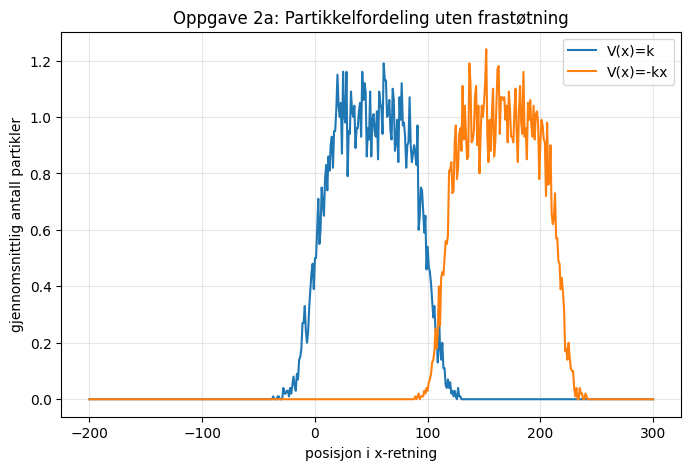

In [510]:
plot_oppgave_2_a_b(oppgave_2a, params_oppave_2, 
                  "Oppgave 2a: Partikkelfordeling uten frastøtning")

# Oppgave 2b)

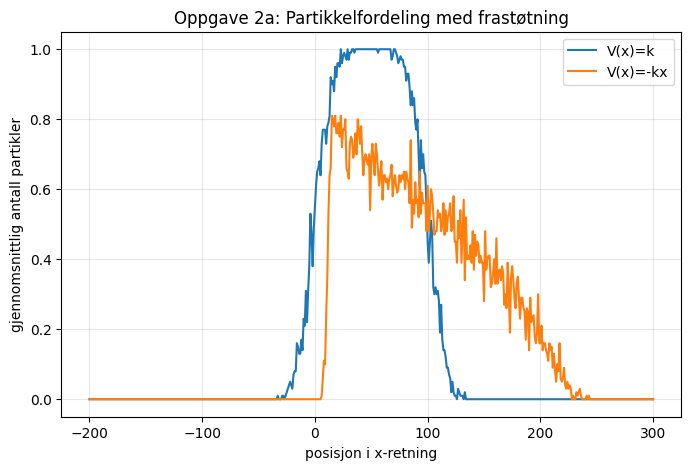

In [511]:
plot_oppgave_2_a_b(oppgave_2b, params_oppave_2, 
                  "Oppgave 2a: Partikkelfordeling med frastøtning")

# Oppgave 2c)

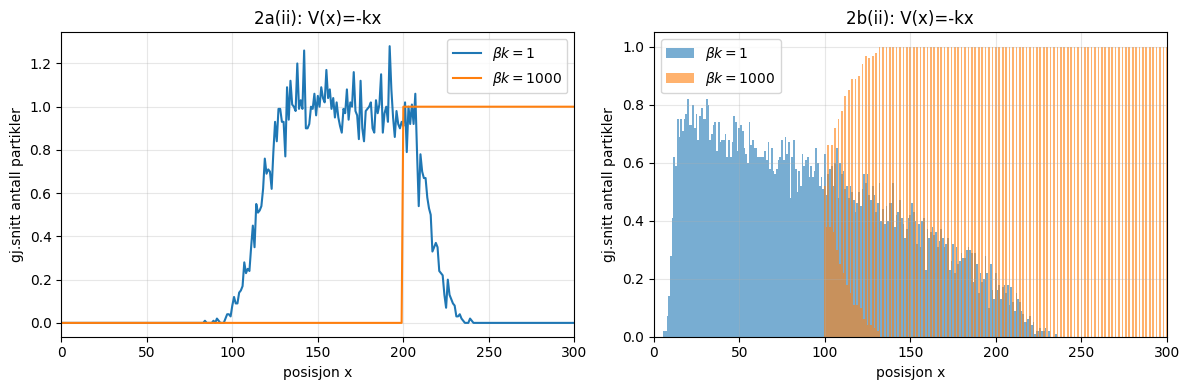

In [512]:
plot_2c(params_oppave_2)